### Import data

In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
from factor_analyzer import FactorAnalyzer
import sys
import os

sys.path.append(os.path.abspath(".."))  
sys.path.append(os.path.abspath("./src"))  

from src.model import  self_calculate_bartlett_sphericity, filter_variables_by_kmo
from src.visualization import plot_factor_loadings


# Load dataset file with labels and features (FCC)
data_path = "../data/"
audio_path = "../audios/"


dataset ='Dataset_1/'
#dataset ='Dataset_2/'
#dataset ='Automatic_Labeling_Kyoogu/'

file = 'Labeled_Data_With_Features.xlsx'
df = pd.read_excel(data_path+dataset+file)

df_allFeatures = df[df['Specie ID'] != 'noise']
df_allFeatures = df_allFeatures.dropna(subset=['Specie ID'])
print(df_allFeatures['Specie ID'].value_counts())  
df_allFeatures

Specie ID
Leptodactylus_fuscus           664
Boana_platanera                264
Nyctidromus_albicollis         152
Dendropsophus_microcephalus    144
Leptodactylus_fragilis          61
Troglodytes_aedon               36
Patagioenas_cayennensis         35
Crotophaga_ani                  33
Crypturellus_soui               32
Amazona_amazonica               11
Dendroplex_picus                10
Alouatta_sp                      9
Pitangus_sulphuratus             7
Ortalis_ruficauda                7
Name: count, dtype: int64


,File,Specie ID,Start,End,FminVoc,FmaxVoc,Fdom,FCC1,FCC2,FCC3,...,FCC19,FCC20,FCC21,FCC22,FCC23,SpectralCentroid,Bandwidth,SpectralFlatness,Length,DeltaFreq
18,SMA03126_20210611_200000.wav,Boana_platanera,5.088000,5.237333,1500.0000,2039.0625,1851.219512,-3.083147,-0.731290,0.796960,...,-0.319067,-2.412642,-0.361050,0.544943,0.606507,1773.357902,128.085949,0.712880,0.149333,539.0625
21,SMA03126_20210611_200000.wav,Leptodactylus_fuscus,5.525333,5.653333,1570.3125,2484.3750,2389.824695,-3.628337,0.030753,1.417370,...,-0.843637,-6.868121,-1.807580,-0.714252,0.389285,2030.233177,294.216375,0.677825,0.128000,914.0625
24,SMA03126_20210611_200000.wav,Leptodactylus_fuscus,6.549333,6.698667,1968.7500,2671.8750,2179.481707,-3.000902,1.296263,-1.326203,...,0.286297,-9.289840,-1.733944,1.954030,0.559039,2362.159738,171.439814,0.581228,0.149333,703.1250
26,SMA03126_20210611_200000.wav,Leptodactylus_fuscus,7.349333,7.605333,2085.9375,3140.6250,2647.888720,-3.439667,-3.605385,0.791954,...,0.948079,-4.425283,2.179185,-0.584308,-0.785984,2527.250354,195.304025,0.562240,0.256000,1054.6875
30,SMA03126_20210611_200000.wav,Leptodactylus_fuscus,8.117333,8.330667,1921.8750,2742.1875,2085.777439,-4.890868,-5.107179,-1.697468,...,0.358364,-5.025391,-3.489022,-1.307864,0.486118,2458.999938,185.250099,0.490381,0.213333,820.3125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11444,SMA03286_20210605_073000.wav,Troglodytes_aedon,33.781333,34.656000,3750.0000,4734.3750,4710.000000,-2.851128,-1.276135,0.334210,...,-0.852090,-5.877823,-0.728837,-0.293088,0.028143,4046.865006,242.506221,0.406058,0.874667,984.3750
11445,SMA03286_20210605_073000.wav,Troglodytes_aedon,34.218667,35.200000,1898.4375,3046.8750,2273.071646,0.930230,0.561288,0.049017,...,-0.191794,-6.971759,-1.685574,1.707034,-0.624709,2633.625653,275.569444,0.593010,0.981333,1148.4375
11451,SMA03286_20210605_073000.wav,Troglodytes_aedon,40.192000,41.056000,3867.1875,4851.5625,4874.016768,-3.870054,-2.742670,-1.330915,...,-0.201051,-6.801126,-1.255397,-0.258459,-0.662155,4242.257911,242.899831,0.480747,0.864000,984.3750
11452,SMA03286_20210605_073000.wav,Troglodytes_aedon,40.501333,41.600000,1734.3750,3070.3125,2085.594512,0.454803,0.399003,1.822761,...,-0.799074,-5.195970,-3.508663,1.216374,1.361429,2657.399326,290.015549,0.499189,1.098667,1335.9375


### Divide features and labels, Scale Features

In [27]:
columns_to_remove = ['File','Specie ID','Specie', 'Taxon', 'sonotype', 'Peak Freq']  
df_only_features = df_allFeatures.drop(columns_to_remove, axis=1, errors='ignore') #Dataframe without labels, only features

# Standardize the features
scaler = StandardScaler()
only_features_scaled = scaler.fit_transform(df_only_features)

### Check Multinormality & Correlation Matrix with spearman

HZResults(hz=5860, pval=0.0, normal=False)


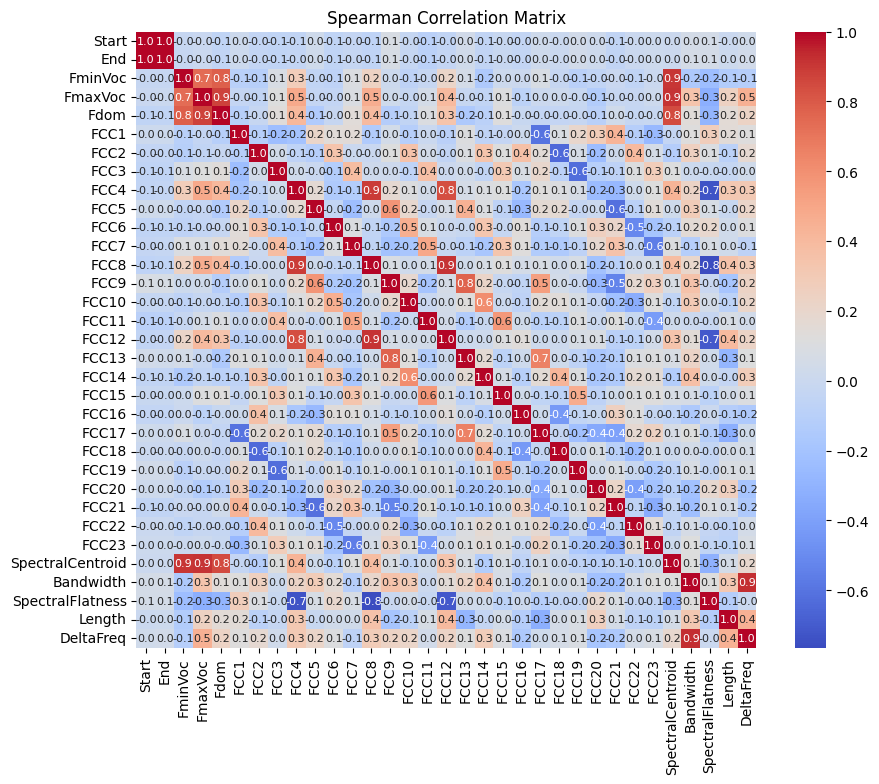

In [28]:
#Normality Test
normality_test = pg.multivariate_normality(only_features_scaled, alpha=0.05)
print(normality_test)

# Convert back to a DataFrame and assign column names
df_only_features_scaled = pd.DataFrame(only_features_scaled, columns=df_only_features.columns)
correlation_matrix = df_only_features_scaled.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".1f", annot_kws={"size": 8})

plt.title('Spearman Correlation Matrix')
plt.show()

## Remove variables with high correlation


In [29]:
# Define the threshold for high correlation
threshold = 0.85

# Create a mask for the upper triangle of the matrix
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Find the variables with high correlation
high_corr_vars = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            colname = correlation_matrix.columns[i]
            high_corr_vars.add(colname)

#high_corr_vars.add('FCC13')
print("Variables with high correlation:", high_corr_vars)

df_only_features_scaled = df_only_features_scaled.drop(columns=high_corr_vars, errors='ignore')



Variables with high correlation: {'Fdom', 'SpectralCentroid', 'FCC12', 'FCC8', 'DeltaFreq', 'End'}


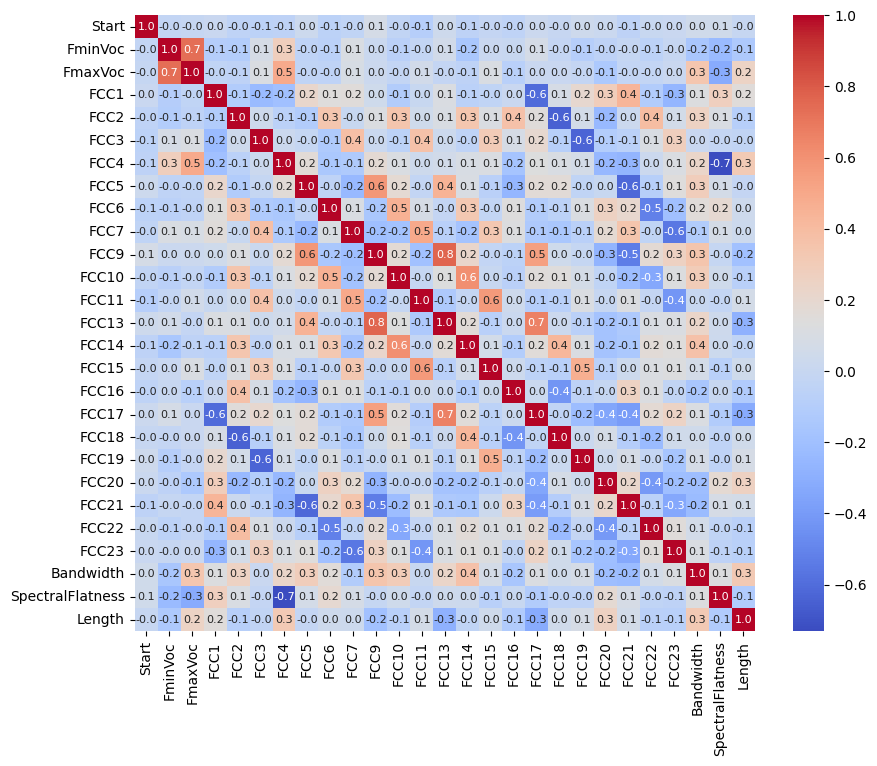

In [30]:
# Display the correlation matrix with a heatmap
plt.figure(figsize=(10, 8))  # Set the size of the figure

# Calculate the correlation matrix using Spearman's method
correlation_matrix_reduced = df_only_features_scaled.corr(method='spearman')

# Generate the heatmap
sns.heatmap(correlation_matrix_reduced, annot=True, cmap='coolwarm', fmt=".1f", annot_kws={"size": 8})

# Show the plot
plt.show()

### Bartlett Test

In [31]:
chi_square_value, p_value = self_calculate_bartlett_sphericity(df_only_features_scaled)
print(f"Results of the Bartlett Test are: Chi-square: {chi_square_value}, p-value: {p_value}")

Results of the Bartlett Test are: Chi-square: 32484.275979041246, p-value: 0.0


### KMO Test

KMO: 0.5145202802047948
Variables with value less than 0.4 are removed.
Detecting variables with low KMO...


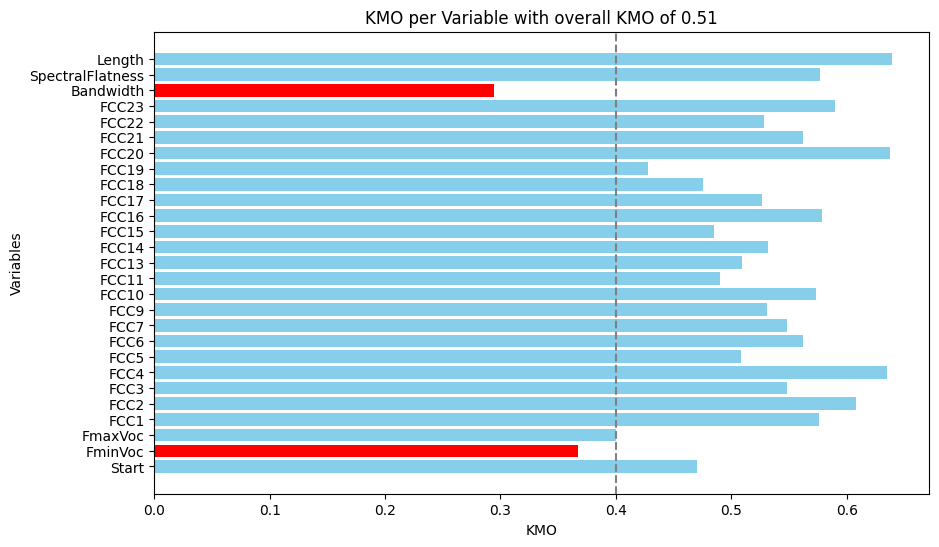

Calculating the new KMO...
The new KMO value after removing variables is: 0.5311542392337002


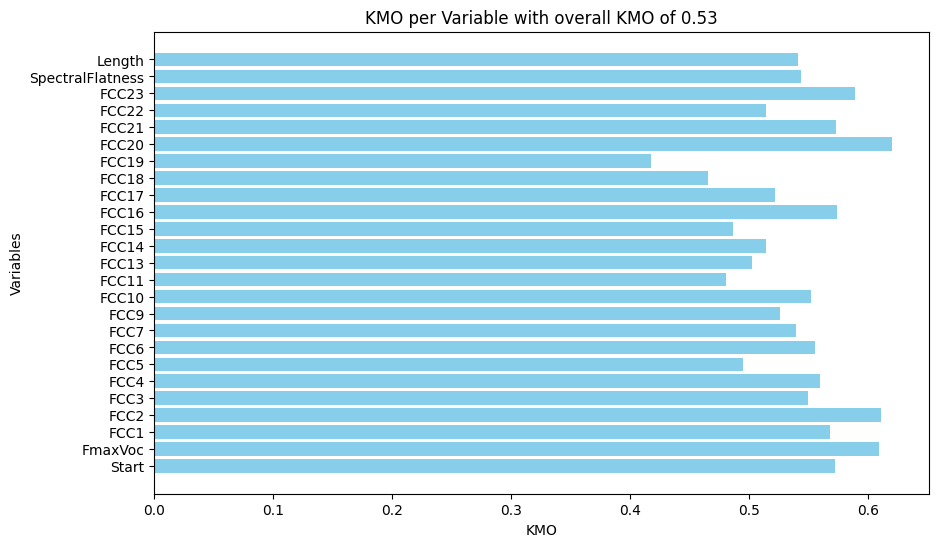

The final KMO value is: 0.5311542392337002
The removed variables are: 
     Variable
0    FminVoc
1  Bandwidth


In [32]:
df_filtered_afterKMO, variables_to_remove = filter_variables_by_kmo(df_only_features_scaled, limit = 0.4)

## Factor Analysis with Varimax Rotation

In [33]:
correlation_matrix_afterKMO = df_filtered_afterKMO.corr(method='spearman')
# Factor Analysis with varimax rotation 
fa1 = FactorAnalyzer(n_factors=3, rotation='varimax', method="minres", is_corr_matrix=True)

# Fit the FactorAnalyzer model on the correlation matrix after KMO filtering
fa1.fit(correlation_matrix_afterKMO)

# Obtain loadings
loadings = fa1.loadings_

# Create a DataFrame with the factor loadings
loadings_df = pd.DataFrame(loadings, columns=[f'Factor{i+1}' for i in range(loadings.shape[1])], index=df_filtered_afterKMO.columns)

print("Factor loadings:")
print(loadings_df)


Factor loadings:
                   Factor1   Factor2   Factor3
Start             0.069763 -0.026103  0.003007
FmaxVoc          -0.101421  0.080269 -0.403003
FCC1             -0.046464 -0.472245  0.243927
FCC2             -0.059878  0.517721  0.505346
FCC3             -0.208340  0.398428 -0.126395
FCC4              0.111756  0.168535 -0.663526
FCC5              0.602886 -0.024546 -0.092717
FCC6              0.021035 -0.229627  0.448057
FCC7             -0.536048  0.012621  0.103687
FCC9              0.687723  0.372330 -0.000861
FCC10             0.393639  0.006190  0.212641
FCC11            -0.396537  0.077914 -0.023554
FCC13             0.527090  0.325115  0.147504
FCC14             0.375715  0.081301  0.147244
FCC15            -0.264615  0.182479 -0.081941
FCC16            -0.289121  0.270210  0.340976
FCC17             0.434007  0.638145 -0.041342
FCC18             0.363227 -0.422153 -0.305109
FCC19            -0.017842 -0.201097  0.052298
FCC20            -0.136900 -0.534388  0.153

### Create Latent Variables

In [34]:
# Assign each variable to the factor with the highest loading
assignment = {}
for variable in loadings_df.index:
    max_loading_factor = loadings_df.loc[variable].abs().idxmax()
    max_loading_value = loadings_df.loc[variable, max_loading_factor]
    if round(abs(max_loading_value), 1) >= 0.35:
        assignment[variable] = (max_loading_factor, round(max_loading_value, 1))

# Create the latent variables (factors)
latent_variables = {f'Factor{i+1}': np.zeros(len(df_filtered_afterKMO)) for i in range(loadings.shape[1])}

for variable, (factor, weight) in assignment.items():
    latent_variables[factor] += weight * df_only_features[variable]

# Convert to DataFrame
df_latent = pd.DataFrame(latent_variables)

print("Latent Variables (factors):")
print(df_latent.head())


Latent Variables (factors):
      Factor1   Factor2      Factor3
18  -1.199992  3.504971  -802.455241
21   7.139431  6.651630  -983.474546
24   4.878908  8.702904 -1060.409103
26 -11.914390  1.998143 -1242.348098
30   6.679592  1.986054 -1091.249990


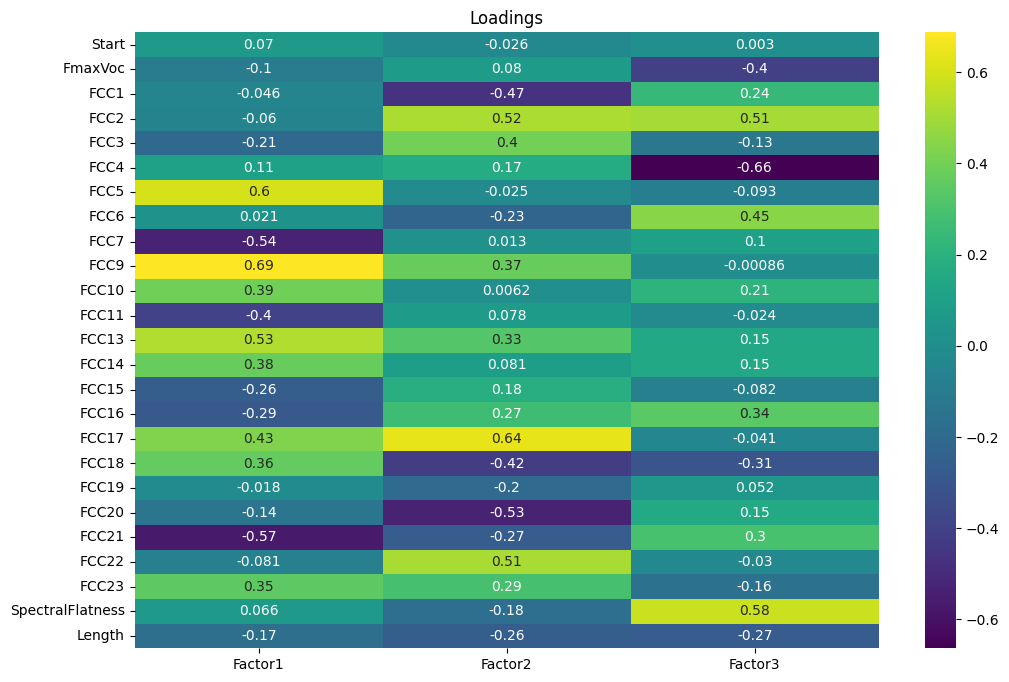

In [35]:
# Ploting the loadings
plt.figure(figsize=(12, 8))
sns.heatmap(loadings_df, annot=True, cmap='viridis')
plt.title('Loadings')
plt.show()

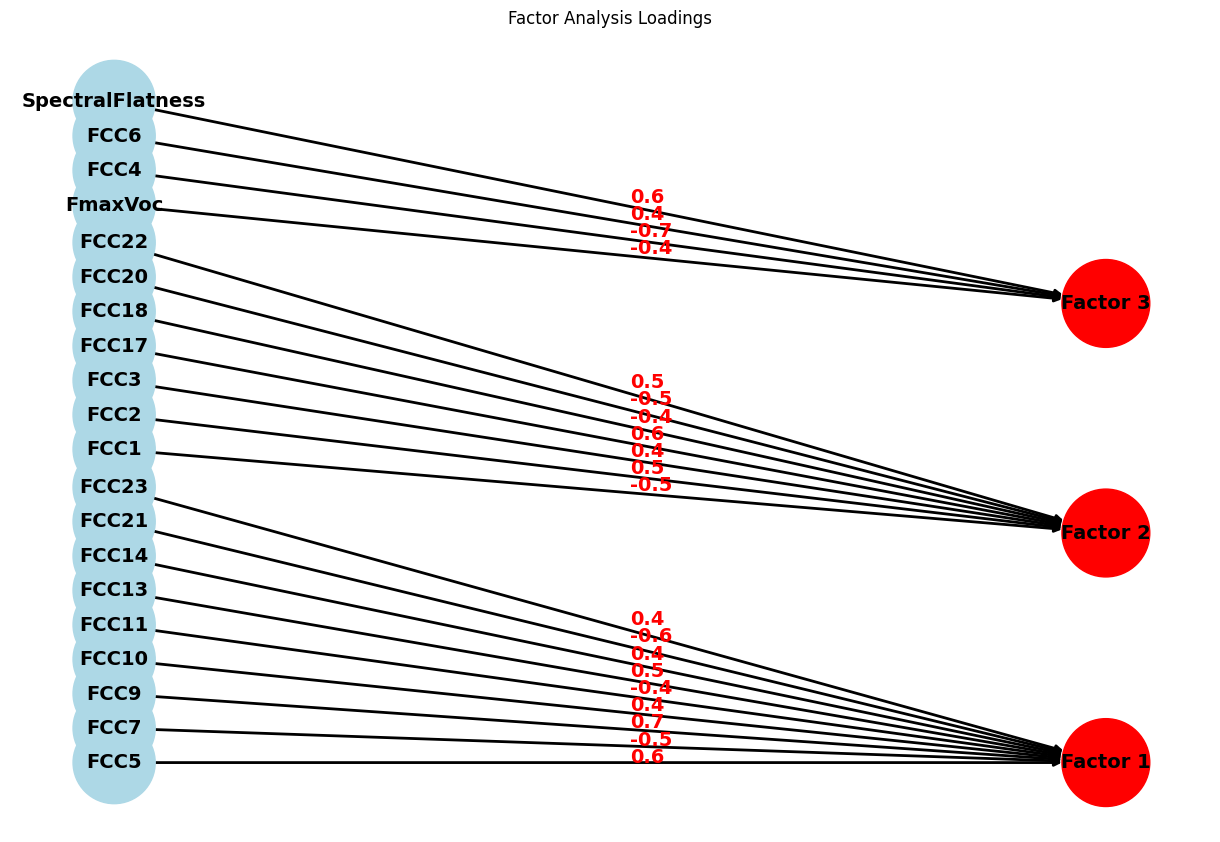

In [36]:
plot_factor_loadings(loadings_df)

### Create new dataset only with the latent variables and removed variables from KMO.

In [37]:
# Filter variables from variables_to_remove that do not start with "FCC"
variables_to_add = variables_to_remove[~variables_to_remove['Variable'].str.startswith('FCC')]

# Select the corresponding columns in df_only_features
Removed_Variables = df_only_features[variables_to_add['Variable']]

# Concatenate the filtered columns to df_reduced
df_reduced2 = pd.concat([df_latent, Removed_Variables], axis=1)
df_reduced2['Specie_ID'] = df_filtered['Specie ID']

# Verify the result
print("Combined DataFrame:")
print(df_reduced2.head())

outputfile = 'reduced_dataframe_FA2.xlsx'
#df_reduced2.to_excel(data_path+dataset+outputfile,index=True)


Combined DataFrame:
      Factor1   Factor2      Factor3    FminVoc   Bandwidth  \
18  -1.199992  3.504971  -802.455241  1500.0000  128.085949   
21   7.139431  6.651630  -983.474546  1570.3125  294.216375   
24   4.878908  8.702904 -1060.409103  1968.7500  171.439814   
26 -11.914390  1.998143 -1242.348098  2085.9375  195.304025   
30   6.679592  1.986054 -1091.249990  1921.8750  185.250099   

                   Specie_ID  
18  Leptopogon superciliaris  
21                       NaN  
24                 Hyloxalus  
26                 Hyloxalus  
30                 Hyloxalus  
